In [1]:
text = [ 'All that we are is the result of what we have thought',
         'To be or not to be that is the question',
         'Be yourself everyone else is already taken' ]

text

['All that we are is the result of what we have thought',
 'To be or not to be that is the question',
 'Be yourself everyone else is already taken']

In [ ]:
import re

allwords = re.split(r'\s',' '.join(text).lower())
allwords

In [ ]:
vocab = sorted(set(allwords))
vocab

In [17]:
word2idx = {}
for i,word in enumerate(vocab):
  word2idx[word] = i
word2idx

{'all': 0,
 'already': 1,
 'are': 2,
 'be': 3,
 'else': 4,
 'everyone': 5,
 'have': 6,
 'is': 7,
 'not': 8,
 'of': 9,
 'or': 10,
 'question': 11,
 'result': 12,
 'taken': 13,
 'that': 14,
 'the': 15,
 'thought': 16,
 'to': 17,
 'we': 18,
 'what': 19,
 'yourself': 20}

In [16]:
idx2word = {}
for i,word in enumerate(vocab):
  idx2word[i] = word
idx2word

{0: 'all',
 1: 'already',
 2: 'are',
 3: 'be',
 4: 'else',
 5: 'everyone',
 6: 'have',
 7: 'is',
 8: 'not',
 9: 'of',
 10: 'or',
 11: 'question',
 12: 'result',
 13: 'taken',
 14: 'that',
 15: 'the',
 16: 'thought',
 17: 'to',
 18: 'we',
 19: 'what',
 20: 'yourself'}

In [18]:
import numpy as np
randidx = np.random.randint(0,len(vocab),size=5)

# words of wisdom as a list of tokens
[ idx2word[i] for i in randidx ]

['taken', 'already', 'all', 'to', 'are']

In [19]:
' '.join([ idx2word[i] for i in randidx ])

'taken already all to are'

In [22]:
text_as_int = [ word2idx[word] for word in allwords ]
text_as_int

[0,
 14,
 18,
 2,
 7,
 15,
 12,
 9,
 19,
 18,
 6,
 16,
 17,
 3,
 10,
 8,
 17,
 3,
 14,
 7,
 15,
 11,
 3,
 20,
 5,
 4,
 7,
 1,
 13]

In [23]:
for tokeni in text_as_int:
  print(f'Token {tokeni:2}: {idx2word[tokeni]}')

Token  0: all
Token 14: that
Token 18: we
Token  2: are
Token  7: is
Token 15: the
Token 12: result
Token  9: of
Token 19: what
Token 18: we
Token  6: have
Token 16: thought
Token 17: to
Token  3: be
Token 10: or
Token  8: not
Token 17: to
Token  3: be
Token 14: that
Token  7: is
Token 15: the
Token 11: question
Token  3: be
Token 20: yourself
Token  5: everyone
Token  4: else
Token  7: is
Token  1: already
Token 13: taken


In [ ]:
word2idx = { word:i for i,word in enumerate(vocab) }
idx2word = { i:word for i,word in enumerate(vocab) }
word2idx   

In [25]:
def encoder(text):
    words = re.split(' ', text.lower()) 
    return [ word2idx[w] for w in words ]
    

### now for the decoder
def decoder(indices):

  # find the words for these indices, and join into one string
  return ' '.join([ idx2word[i] for i in indices ])

In [26]:
# create a new sentence using the vocab
newtext = 'we already are the result of what ' \
          'everyone else already thought'

newtext_tokenIDs = encoder(newtext)
decoded_text = decoder(newtext_tokenIDs)

print('Original text:')
print(f'\t{newtext}')

print(f'\nToken IDs:')
print(f'\t{newtext_tokenIDs}')

print(f'\nDecoded text:')
print(f'\t{decoded_text}')

Original text:
	we already are the result of what everyone else already thought

Token IDs:
	[18, 1, 2, 15, 12, 9, 19, 5, 4, 1, 16]

Decoded text:
	we already are the result of what everyone else already thought


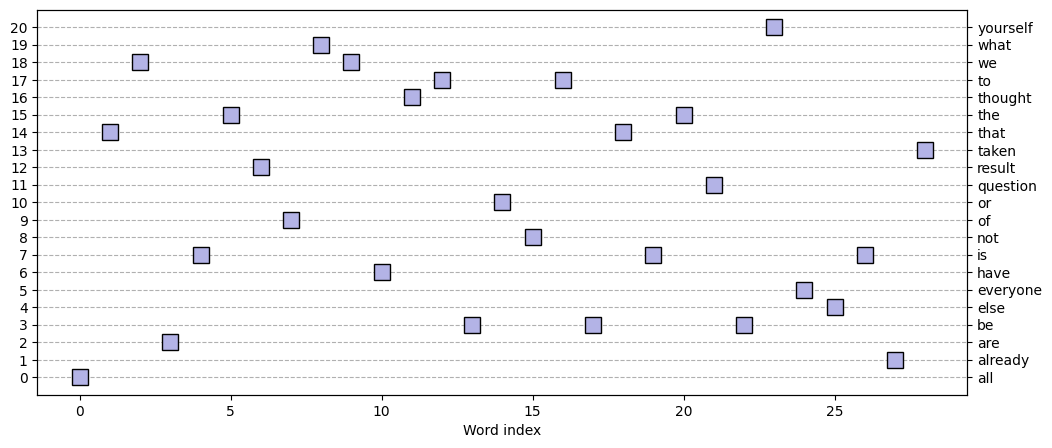

In [27]:
# get all the text and all the tokens
import matplotlib.pyplot as plt
alltext = ' '.join(text)
tokens = encoder(alltext)

# create a figure
_,ax = plt.subplots(1,figsize=(12,5))

# plot the tokens
ax.plot(tokens,'ks',markersize=12,markerfacecolor=[.7,.7,.9])
ax.set(xlabel='Word index',yticks=range(len(vocab)))
ax.grid(linestyle='--',axis='y')

# invisible axis for right-hand-side labels
ax2 = ax.twinx()
ax2.plot(tokens,alpha=0)
ax2.set(yticks=range(len(vocab)),yticklabels=vocab)

plt.show()

In [28]:
targetWord = 'to'
targetIdx = word2idx[targetWord]
print(targetIdx)

# find indices
targetLocs = np.where(np.array(allwords) == targetWord)[0]
print(f'"{targetWord}" appears at indices {targetLocs}\n\n')

print(np.where(np.array(allwords) == targetWord))

# print context
for t in targetLocs:
  print(tokens[t-1:t+2])
  print(' '.join(allwords[t-1:t+2]),'\n')

17
"to" appears at indices [12 16]


(array([12, 16]),)
[16, 17, 3]
thought to be 

[8, 17, 3]
not to be 



In [29]:
word_matrix = np.zeros((len(allwords),len(vocab)),dtype=int)

# create the matrix
for i,word in enumerate(allwords):
  word_matrix[i,word2idx[word]] = 1

# show the results
print(f'One-hot encoding matrix is of size {word_matrix.shape}\n')
print(word_matrix)

One-hot encoding matrix is of size (29, 21)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 

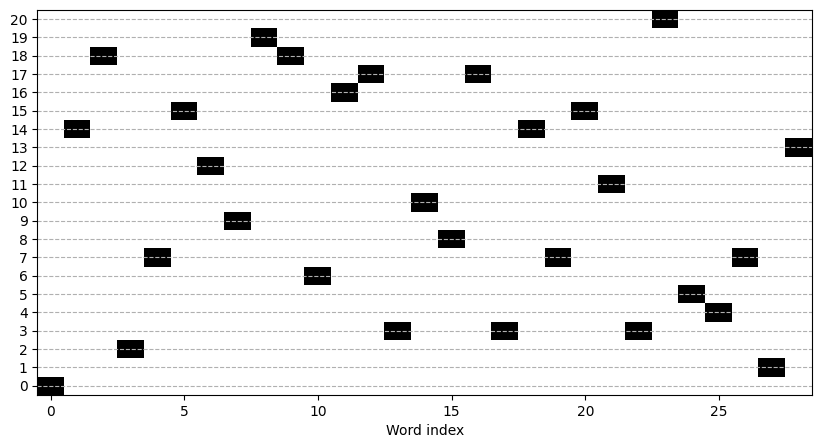

In [30]:
# the image of the one-hot encoding matrix is the same as in Exercise 2
_,ax = plt.subplots(1,figsize=(10,5))

plt.imshow(1-word_matrix.T,cmap='gray',origin='lower',aspect='auto')
ax.set(xlabel='Word index',yticks=range(len(vocab)))
ax.grid(linestyle='--',axis='y')
plt.show()